# Project notebook - Unsupervised Machine Learning
### K-Means clustering and PCA 

The goal of this project is to create playlists of 50-100 songs with a similar mood from a dataset of 5000 songs based on various features

---
### 1. Load data and packages

In [ ]:
import pandas as pd
import numpy as np

from sklearn.cluster import KMeans
from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn import set_config
set_config(transform_output="pandas")

In [2]:
songs_df = pd.read_csv('../data/3_spotify_5000_songs.csv', index_col=0)

#remove whitespace
songs_df.columns = songs_df.columns.str.strip()
songs_df['name'] = songs_df['name'].str.strip()

#remove duplicates
print(f'songs_df before removing duplicates: {songs_df.shape}')
songs_df = songs_df.drop_duplicates()
print(f'songs_df after removing duplicates: {songs_df.shape}')

#remove non-numeric rows and set index as name and artist
songs_num_df = songs_df.set_index(['name', 'artist']).select_dtypes('number')

songs_df before removing duplicates: (5235, 18)
songs_df after removing duplicates: (5171, 18)


In [3]:
songs_num_df.sample(10)

,,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,time_signature
name,artist,,,,,,,,,,,,,
Blinding Lights - Piano Version,Flying Fingers,0.358,0.0123,0,-27.600,0,0.0600,0.994000,0.945000,0.1190,0.1800,148.729,121000,4
Paranoid Android,Brad Mehldau,0.385,0.5730,7,-13.027,0,0.0449,0.669000,0.886000,0.0932,0.1210,100.988,545013,4
Silence - Tiësto's Big Room Remix,Marshmello,0.522,0.9410,1,-3.357,0,0.2500,0.006210,0.000004,0.9560,0.0994,130.088,202154,4
Autumn Leaves,Chet Baker,0.496,0.6340,5,-10.328,0,0.0364,0.779000,0.402000,0.0746,0.6060,93.357,423573,4
"Alabama - Live At Birdland Jazzclub, New York City, NY, 10/18/1963",John Coltrane,0.428,0.0768,0,-17.412,0,0.0413,0.774000,0.048700,0.1230,0.1120,107.712,308933,4
Dells of Pain,Blasphereion,0.275,0.7460,7,-15.441,1,0.0668,0.000047,0.956000,0.3610,0.1770,132.383,242293,4
HeadBand (feat. 2 Chainz),B.o.B,0.920,0.4720,1,-7.941,1,0.3330,0.166000,0.000000,0.0680,0.3080,97.463,219833,4
Sister Big Stuff,John Holt,0.770,0.4180,8,-7.834,1,0.1330,0.574000,0.000003,0.0861,0.9300,83.041,151133,4
A Message to You Rudy - 2002 Remastered Version,The Specials,0.906,0.4500,0,-8.003,1,0.0627,0.149000,0.000232,0.1680,0.9690,103.476,172600,4


In [4]:
#How many unique artists are there?
print(f'{songs_df["artist"].nunique()} unique artists in the dataset')

2176 unique artists in the dataset


### 2. Manual feature selection

Drop the following columns:
- key (despite being represented by numbers, it's not truly numeric - it's using pitch class to represent keys, and there is a circular relationship in keys (C=0, and B=11 appear far from each other in numeric format, but actually they are very close))
- time-signature (3 (3/4 time I guess?) is not really 1 away from 4 (4/4 time), for example - not meaningful musically)

In [5]:
songs_selected_df = songs_num_df.drop(columns=['key', 'time_signature'])
songs_selected_df.sample(10)

,,danceability,energy,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms
name,artist,,,,,,,,,,,
Church of Lies,Blasphereion,0.261,0.706,-16.755,1,0.0547,0.000030,0.954000,0.1560,0.141,124.966,333933
"Here We Go (Hey Boy, Hey Girl)",Dimitri Vegas & Like Mike,0.583,0.979,-3.830,1,0.0398,0.001410,0.902000,0.0600,0.267,126.028,158095
Spank - Radio Edit,The Bloody Beetroots,0.499,0.923,-3.638,1,0.0601,0.002190,0.757000,0.1980,0.204,129.033,223320
Succubus,Massacre,0.421,0.975,-9.621,1,0.0890,0.000124,0.812000,0.2250,0.422,108.554,182853
The Loser,Derrick Harriott,0.571,0.371,-9.799,1,0.0348,0.321000,0.000220,0.0583,0.789,176.814,217013
Cello (feat. Clueso) - MTV Unplugged Radio Atmo-Version,Udo Lindenberg,0.524,0.681,-7.289,0,0.0812,0.623000,0.000076,0.8970,0.450,88.974,218707
Superheroes,The Script,0.490,0.885,-4.121,1,0.0396,0.002180,0.000000,0.0741,0.640,166.996,245467
Yesterday,David Schultz,0.319,0.163,-15.653,1,0.0623,0.981000,0.923000,0.1120,0.169,163.209,166000
Grey,Kölsch,0.833,0.582,-6.987,0,0.0659,0.053000,0.057700,0.1080,0.209,125.026,293579


### 3. Preprocessing - scale and transform data

In [6]:
scaler = MinMaxScaler()
songs_selected_scaled = scaler.fit_transform(songs_selected_df)
songs_selected_scaled.sample(10)

,,danceability,energy,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms
name,artist,,,,,,,,,,,
"Music for Strings, Percussion and Celesta, BB 114: II. Allegro",Béla Bartók,0.399173,0.124,0.605311,0.0,0.047930,0.948795,0.930964,0.086424,0.323858,0.665017,0.108682
Miss Independent,Ne-Yo,0.690796,0.673,0.884973,1.0,0.157952,0.481928,0.000000,0.196555,0.738071,0.802897,0.052667
Anointed in Servitude,Internal Bleeding,0.350569,0.868,0.807783,1.0,0.140523,0.000038,0.947208,0.087943,0.278173,0.827099,0.067724
Venus - Bonus Track,Frankie Avalon,0.543950,0.488,0.771983,1.0,0.032244,0.603414,0.000013,0.095238,0.728934,0.538315,0.028873
Malicious Intent,Napalm Death,0.373320,0.858,0.748036,1.0,0.131808,0.000027,0.763452,0.252280,0.438579,0.528543,0.045893
My Edward and I (feat. Jack Liebeck),Dario Marianelli,0.097725,0.057,0.575902,1.0,0.051852,0.979920,0.409137,0.092199,0.038071,0.315893,0.053181
Für immer,Unheilig,0.580145,0.900,0.884663,1.0,0.048693,0.002098,0.000071,0.040628,0.627411,0.644829,0.045530
Inevitale Demise,Necrosanct,0.184074,0.987,0.853983,1.0,0.095316,0.000017,0.912690,0.362715,0.116751,0.454568,0.056420
Let Me Entertain You,Robbie Williams,0.494312,0.965,0.896254,1.0,0.069935,0.000170,0.002548,0.086525,0.352284,0.584850,0.060597


### 4. PCA

Use PCA with a cumulative variance threshold to define cutoff for number of PCs

In [7]:
# Create a PCA object
pca_variance = PCA(n_components = 0.95)

Apply to the scaled, feature-selected data

In [8]:
# Fit the PCA object to the scaled features dataframe and transform it
pca_variance_df = pca_variance.fit_transform(songs_selected_scaled)

# The dataframe now contains the principal components of the scaled features dataframe
pca_variance_df

,,pca0,pca1,pca2,pca3,pca4,pca5
name,artist,,,,,,
Se Eu Quiser Falar Com Deus,Gilberto Gil,0.045158,-0.684826,-0.516291,-0.283897,0.570726,0.550322
Saudade De Bahia,Antônio Carlos Jobim,-0.102002,0.397905,-0.381457,0.098459,-0.176692,0.039544
"Canta Canta, Minha Gente",Martinho Da Vila,-0.217599,0.431928,-0.468649,0.291033,-0.012442,0.039595
Mulher Eu Sei,Chico César,0.468190,0.237404,-0.812933,-0.072536,0.110753,0.219174
Rosa Morena,Kurt Elling,0.525377,0.222483,-0.750972,-0.159917,-0.080404,0.008964
...,...,...,...,...,...,...,...
"1812 Festival Overture, Op. 49: 1812 Overture, Op. 49",Pyotr Ilyich Tchaikovsky,1.168891,0.026580,-0.119175,-0.112600,-0.081784,-0.000312
"Winter Fragments pour ensemble instrumental, sons de synthèse et dispositif électronique",Tristan Murail,0.980328,0.088783,-0.216103,-0.317363,-0.097419,-0.024566
"Schoenberg: 5 Orchestral Pieces, Op. 16: No. 3 Farben (Colours)",Arnold Schoenberg,1.449670,-0.056136,0.008842,-0.021489,-0.086184,-0.004520


### 5. Apply K-Means clustering to PCA dataset

explore k=20 - k=100 clusters for the playlists to be 50-250 songs
increase n_init to 50 and try different random seeds  

NB! this will take a while (~20 mins) - load the saved data below instead of running the next cell

In [ ]:
random_seeds = [808, 5678, 1234, 121234, 123223, 42, 69]
data = pca_variance_df

#set up lists to store inertia and silhouette scores
seeds = []
inertia_scores = []
sil_scores = []

#set k values
kmin = 20
kmax = 100

#loop through random seeds and k values
for seed in random_seeds:

    for k in range(kmin, kmax+1):
        kmeans = KMeans(n_clusters=k, random_state=seed, n_init=50)
        kmeans.fit(data)

        #get inertia and add it to the list
        inertia_scores.append(kmeans.inertia_)

        #get silhouette score and add it to the list
        labels = kmeans.labels_
        sil_scores.append(silhouette_score(data, labels))

        #store random seed value
        seeds.append(seed)

In [ ]:
#Save results
plotdata = pd.DataFrame({
    "k": list(range(kmin, kmax+1)) * len(random_seeds),
    'inertia': inertia_scores,
    'sil': sil_scores,
    'seed':seeds
})

plotdata.to_csv('../data/project_minmaxscaler_loop_output.csv', index=False)

Plot silhouette scores and inertia scores

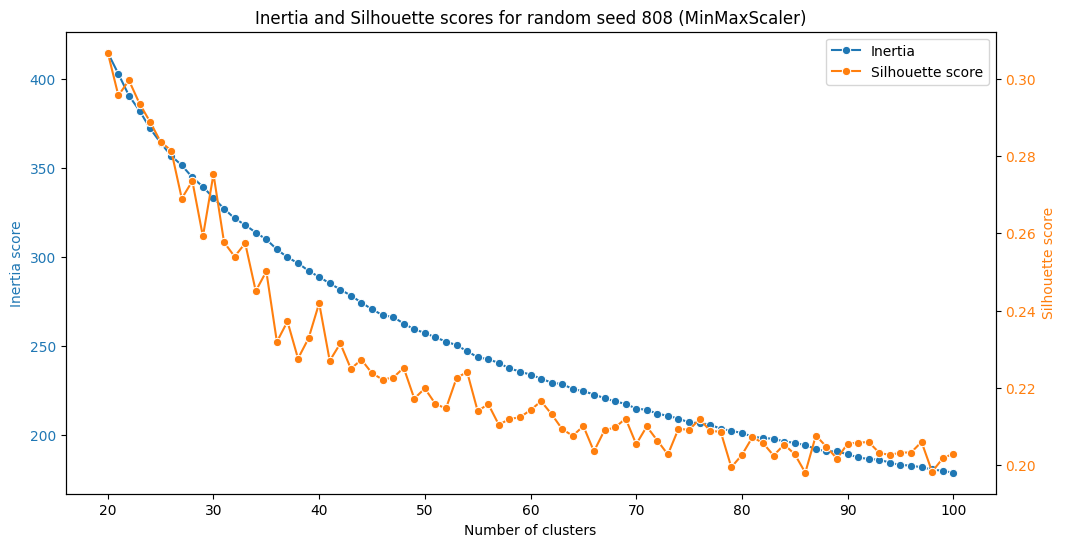

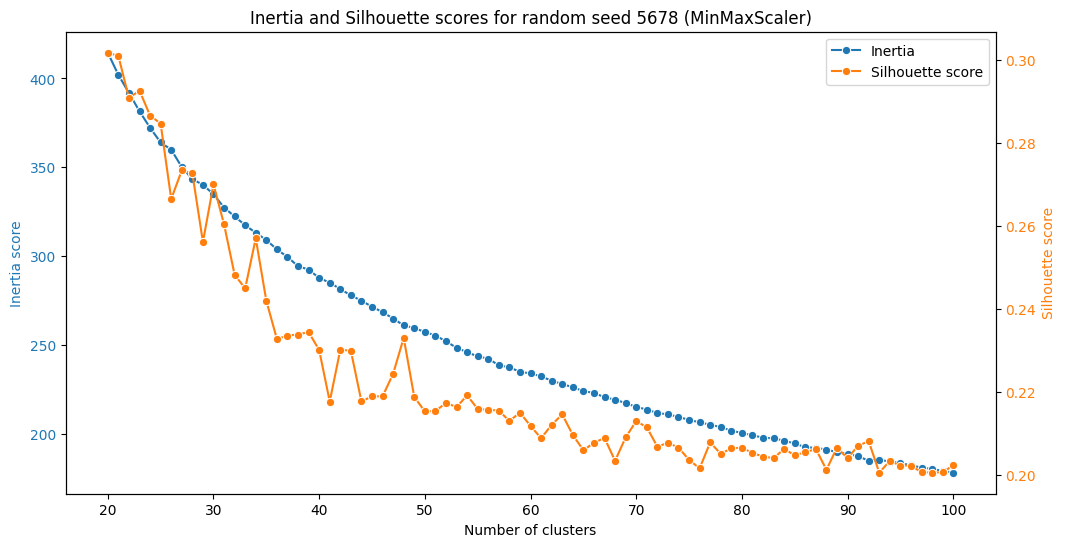

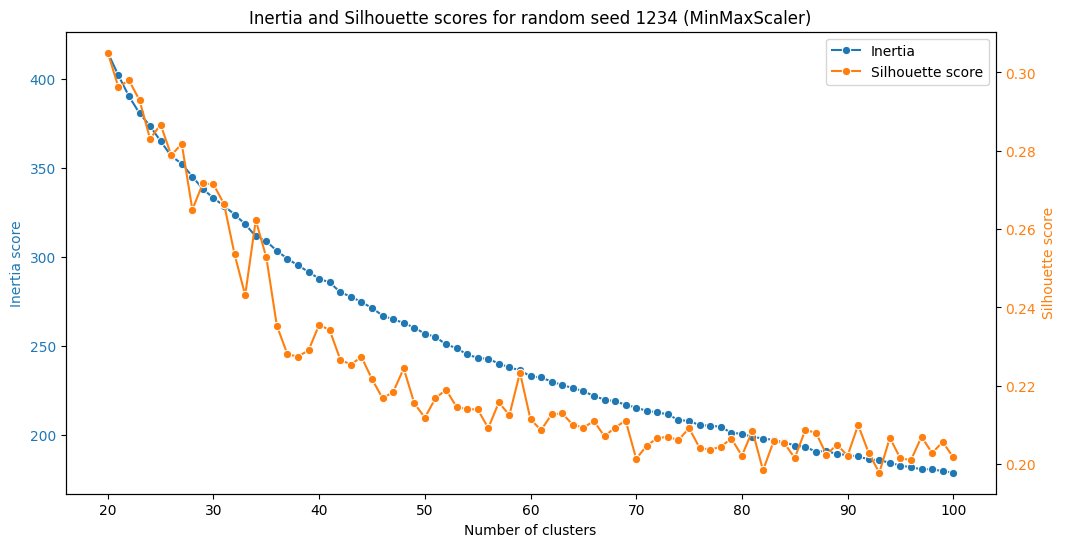

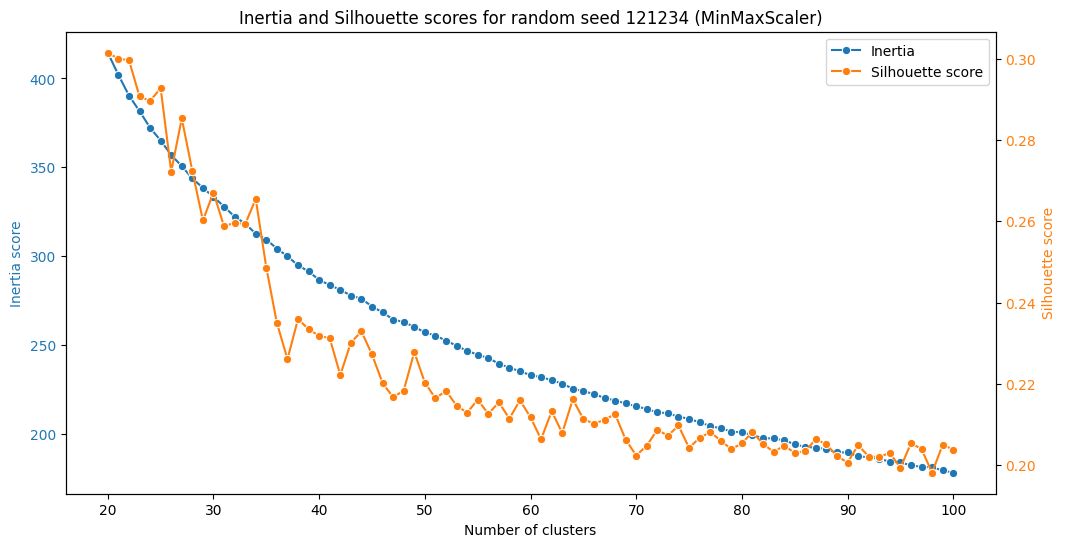

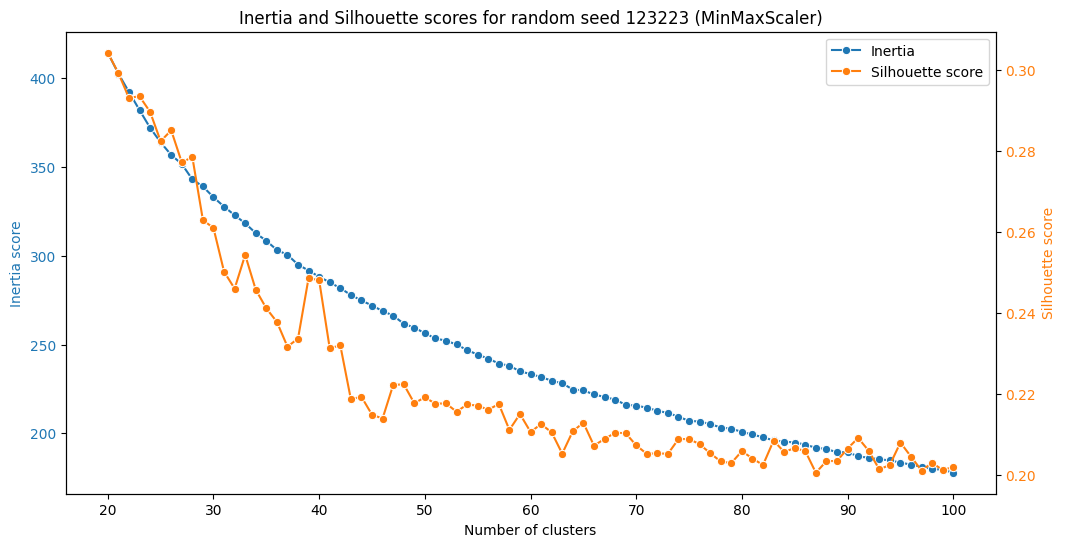

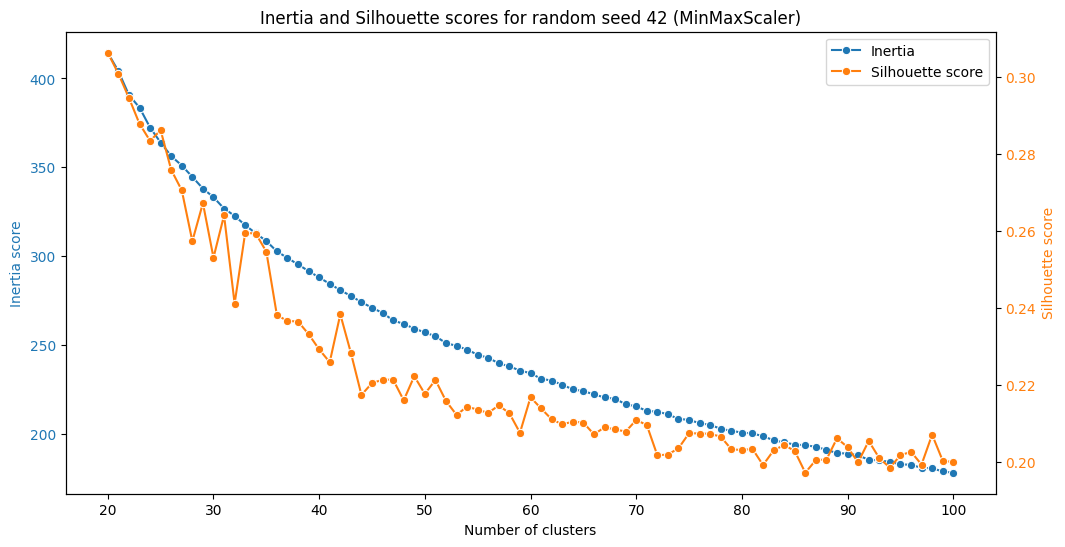

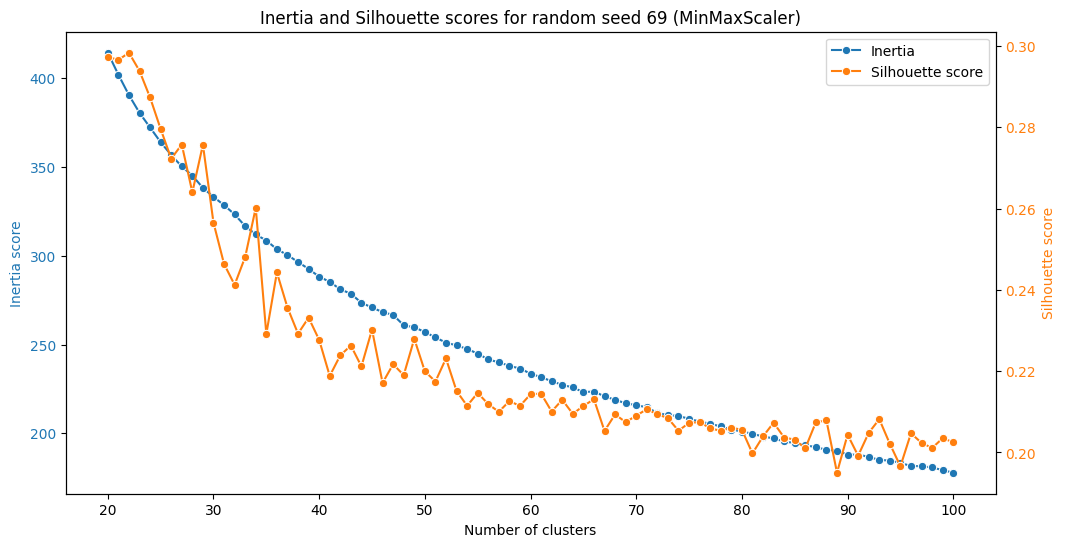

In [ ]:
# Combined plot (multiple random seeds)

# read in the saved data
plotdata = pd.read_csv('../data/project_minmaxscaler_loop_output.csv')


# Loop through unique seeds
for seed in plotdata['seed'].unique():
    df_seed = plotdata[plotdata['seed'] == seed]  # select rows for this seed

    fig, ax1 = plt.subplots(figsize=(12,6))

    # Inertia
    l1 = sns.lineplot(
        data=df_seed,
        x='k',
        y='inertia',
        marker='o',
        color='tab:blue',
        ax=ax1
    )
    ax1.set_xlabel("Number of clusters")
    ax1.set_ylabel("Inertia score", color="tab:blue")
    ax1.tick_params(axis='y', labelcolor="tab:blue")

    # Silhouette on secondary axis
    ax2 = ax1.twinx()
    l2 = sns.lineplot(
        data=df_seed,
        x='k',
        y='sil',
        marker='o',
        color='tab:orange',
        ax=ax2
    )
    ax2.set_ylabel("Silhouette score", color="tab:orange")
    ax2.tick_params(axis='y', labelcolor="tab:orange")

    # Legend
    ax1.legend([l1.lines[0], l2.lines[0]], ["Inertia", "Silhouette score"])

    plt.title(f"Inertia and Silhouette scores for random seed {seed} (MinMaxScaler)")
    plt.show()

Inertia scores are difficult to make decisions on here - no clear elbow.  
Find the largest silhouette scores when n_clusters is > 80

In [10]:
plotdata.loc[plotdata['k']>80].sort_values('sil', ascending=False).head()

,k,inertia,sil,seed
233,91,188.046172,0.209947,1234
395,91,187.051269,0.209204,123223
228,86,193.394292,0.208659,1234
387,83,196.070146,0.208534,123223
223,81,199.031773,0.208490,1234


Let's explore the playlists created with seed = 1234, k = 91, n_init = 50

In [11]:
kmeans = KMeans(n_clusters=91, random_state=1234, n_init=50)
kmeans.fit(pca_variance_df)
labels = kmeans.labels_
songs_num_df['clusters'] = labels

In [12]:
songs_num_df.groupby('clusters').sample(5)

,,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,time_signature,clusters
name,artist,,,,,,,,,,,,,,
Ask - 2011 Remaster,The Smiths,0.453,0.986,7,-5.768,1,0.1190,0.387,0.000000,0.4220,0.4550,166.594,198147,4,0
The Right Song,Tiësto,0.546,0.894,8,-3.560,1,0.0898,0.459,0.000106,0.3220,0.3870,125.031,205440,4,0
Don't Let the Sun Go Down on Me,George Michael,0.432,0.551,0,-8.096,1,0.0289,0.501,0.000002,0.4720,0.2530,136.465,346960,4,0
Let There Be Peace On Earth - Live,Ricky Dillard,0.194,0.642,11,-6.933,1,0.0574,0.365,0.000000,0.7120,0.2640,164.546,453049,3,0
Cari,Senior i el cor brutal,0.487,0.659,9,-8.049,1,0.0338,0.216,0.006290,0.3360,0.5020,124.986,165279,4,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Vomit Floods of Christian Remains,Imprecation,0.215,0.716,9,-17.937,1,0.0468,0.333,0.919000,0.1550,0.1060,82.767,376973,4,90
Du cristal,Kaija Saariaho,0.160,0.202,1,-23.674,1,0.0482,0.279,0.865000,0.0549,0.0377,132.215,999707,3,90
The Quest of Absurdity,Asphyx,0.234,0.139,2,-22.055,1,0.0341,0.130,0.940000,0.1100,0.1030,81.606,80893,3,90


In [44]:
songs_num_df.to_csv('../data/clustered_songs.csv')

### 6. Classify centroids

Which features is each cluster representing?

In [78]:
#how many songs per cluster
songs_num_df.groupby('clusters').size().describe()

count     91.000000
mean      56.824176
std       32.872005
min        5.000000
25%       29.500000
50%       54.000000
75%       77.500000
max      168.000000
dtype: float64

In [39]:
#get centroids
centroids_pca = kmeans.cluster_centers_

#transform them backl to scaled feature space
centroids_scaled = pca_variance.inverse_transform(centroids_pca)

#undo scaling to get values on original feature units
#centroids_original = scaler.inverse_transform(centroids_scaled)

#put into a dataframe
feature_names = songs_selected_scaled.columns
centroid_df = pd.DataFrame(
    centroids_scaled,
    columns=feature_names
)

centroid_df.index.name = "cluster"
centroid_df

,danceability,energy,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms
cluster,,,,,,,,,,,
0,0.406274,0.693336,0.842944,0.999817,0.097055,0.397224,0.025919,0.428817,0.396990,0.584684,0.057133
1,0.596349,0.840694,0.898019,0.000012,0.107476,0.039181,0.028318,0.118129,0.542272,0.607754,0.050915
2,0.362456,0.141733,0.659705,1.000175,0.048682,0.924481,0.513716,0.143847,0.165728,0.481870,0.071895
3,0.750654,0.447547,0.802354,1.000197,0.063515,0.624793,0.012503,0.197985,0.877057,0.570505,0.047022
4,0.144206,0.957033,0.834973,0.997831,0.104271,0.005584,0.850072,0.124113,0.236513,0.662463,0.063480
...,...,...,...,...,...,...,...,...,...,...,...
86,0.627243,0.393107,0.725284,-0.000539,0.064750,0.622240,0.813288,0.162433,0.635427,0.511416,0.059775
87,0.756998,0.836021,0.906310,1.000759,0.095369,0.050390,0.016841,0.100002,0.852599,0.603234,0.042303
88,0.662690,0.883898,0.914274,0.000139,0.114590,0.059415,0.026798,0.330740,0.659057,0.586335,0.048017


In [41]:
#select some random clusters to present
centroid_df.sample(5)

,danceability,energy,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms
cluster,,,,,,,,,,,
51,0.706013,0.851467,0.911700,-0.000238,0.126301,0.185331,0.000338,0.735095,0.619963,0.496235,0.049975
34,0.384663,0.924479,0.902497,0.001217,0.113044,0.043252,0.052036,0.175149,0.407189,0.673889,0.054389
75,0.546835,0.354480,0.764771,1.000202,0.080235,0.843183,0.016888,0.696034,0.419993,0.454571,0.060790
60,0.629202,0.813307,0.833308,0.995929,0.104992,0.001704,0.864870,0.284260,0.504298,0.456515,0.057086
73,0.336060,0.944124,0.853889,0.999172,0.123786,0.049712,0.759275,0.612194,0.256944,0.508359,0.062793


In [ ]:
songs_num_df = pd.read_csv('../data/clustered_songs.csv')

In [49]:
#cluster 51 = danceable, loud, high energy, but not so fast songs (hip hop/dance/electronica)
songs_num_df.loc[songs_num_df['clusters']==51].sample(5)

,,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,time_signature,clusters
name,artist,,,,,,,,,,,,,,
Cooler Than Me - Single Mix,Mike Posner,0.768,0.820,7,-4.630,0,0.0474,0.17900,0.000000,0.689,0.625,129.965,213293,4,51
Me Niego (feat. Ozuna & Wisin),Reik,0.777,0.779,0,-4.449,0,0.0972,0.05430,0.000000,0.636,0.768,94.023,221653,4,51
Pump It,Black Eyed Peas,0.648,0.931,1,-3.150,0,0.1810,0.00937,0.000000,0.752,0.744,153.649,213067,4,51
Survivor,Destiny's Child,0.514,0.911,1,-2.027,0,0.4100,0.05590,0.000000,0.775,0.619,161.109,254027,4,51
Born Again (Babylonia),Sunnery James & Ryan Marciano,0.638,0.791,11,-6.891,0,0.0365,0.13100,0.000197,0.567,0.434,126.042,175264,4,51


In [ ]:
#cluster 34 = not danceable, but high energy, loud, high tempo (Metal)
songs_num_df.loc[songs_num_df['clusters']==34].sample(5)

,,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,time_signature,clusters
name,artist,,,,,,,,,,,,,,
The Trooper - 2015 Remaster,Iron Maiden,0.285,0.908,4,-4.601,0,0.0705,0.031800,0.009090,0.3110,0.669,159.756,252733,4,34
Remnants of Withered Decay,Malevolent Creation,0.298,0.888,7,-11.605,0,0.0908,0.000345,0.010600,0.0717,0.344,107.926,234800,4,34
Chop Suey!,System Of A Down,0.420,0.929,7,-3.899,0,0.1210,0.000353,0.000747,0.1220,0.300,127.204,210240,4,34
Whataya Want from Me,Adam Lambert,0.440,0.683,11,-4.732,0,0.0489,0.007060,0.000000,0.0593,0.445,185.948,227320,4,34
Waiting For The Funeral,Post Mortem,0.403,0.930,8,-6.055,0,0.0927,0.034200,0.000003,0.0917,0.317,108.487,183693,4,34


In [70]:
songs_num_df.sample(10)

,,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,time_signature,clusters
name,artist,,,,,,,,,,,,,,
'Til Death,Obituary,0.213,0.9510,11,-7.369,1,0.1310,0.000006,0.000593,0.0548,0.0514,143.252,236467,4,16
"The Planets - Suite for large orchestra, Op.32: I. Mars, the Bringer of War (Allegro)",Gustav Holst,0.198,0.2960,0,-19.854,1,0.0425,0.760000,0.911000,0.3720,0.0712,153.306,445280,5,83
I'll Be Seeing You,Billie Holiday,0.355,0.0304,1,-20.479,1,0.0361,0.989000,0.055500,0.1160,0.1880,90.495,211533,3,48
Slow String Instrumental,Van Vogel Ensemble,0.154,0.0334,2,-28.080,0,0.0506,0.960000,0.829000,0.1050,0.0385,134.424,145747,1,7
Me and Bobby McGee,Janis Joplin,0.430,0.4630,2,-10.960,1,0.0442,0.303000,0.000058,0.1520,0.6600,93.405,271333,4,67
Song For My Father,Horace Silver,0.742,0.6710,5,-8.142,0,0.0407,0.794000,0.004410,0.1220,0.5910,127.359,438280,4,11
"Bizet: Carmen, Act 1: ""L'amour est un oiseau rebelle"" (Carmen, Chorus) [Habanera]",Georges Bizet,0.373,0.1160,2,-16.082,1,0.0590,0.984000,0.000000,0.1220,0.2060,129.793,269227,4,48
Ahora Dice,Chris Jedi,0.704,0.6900,6,-5.451,1,0.1600,0.249000,0.000000,0.1230,0.4020,144.045,271080,4,45
How Long,Charlie Puth,0.845,0.5610,1,-5.253,0,0.0778,0.211000,0.000003,0.0383,0.8110,109.974,200853,4,35


In [ ]:
#cluster 52 = ambient & classical - calm & meditative
songs_num_df.loc[songs_num_df['clusters']==52].sample(5)

,,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,time_signature,clusters
name,artist,,,,,,,,,,,,,,
Wind On Wind,Robert Fripp,0.0673,0.0590,8,-26.134,1,0.0438,0.972,0.930,0.0849,0.0331,70.959,193280,1,52
"Symphony ""Mathis der Maler"": I. Engelkonzert (Angelic Concert)",Paul Hindemith,0.2040,0.0568,7,-23.832,1,0.0420,0.952,0.809,0.0821,0.0385,99.485,564800,4,52
unother,Terekke,0.2450,0.0862,4,-30.304,1,0.0422,0.994,0.784,0.0920,0.0390,69.895,62758,4,52
Andromeda,Applefish,0.2140,0.1580,8,-19.160,1,0.0431,0.949,0.925,0.1120,0.0365,71.436,255000,4,52
Intentions - Piano Version,Flying Fingers,0.3830,0.1110,9,-18.702,1,0.0463,0.989,0.937,0.0979,0.0635,138.066,132500,4,52


In [73]:
#cluster 7 = ambient & classical - calm & meditative
songs_num_df.loc[songs_num_df['clusters']==7].sample(5)

,,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,time_signature,clusters
name,artist,,,,,,,,,,,,,,
Space 11 (Invisible Pages Over),Max Richter,0.1390,0.0895,7,-28.274,0,0.0430,0.875,0.856,0.0638,0.0330,142.191,315720,4,7
Water Memory 1,Emily A. Sprague,0.0657,0.0608,7,-28.669,0,0.0422,0.972,0.963,0.1070,0.0699,66.706,448133,5,7
Beethoven 250,A Winged Victory for the Sullen,0.1290,0.2450,4,-22.343,0,0.0400,0.858,0.936,0.0625,0.0352,93.596,251560,3,7
"Rachmaninoff: Symphony No. 3 in A Minor, Op. 44: I. Lento - Allegro moderato - Allegro",Sergei Rachmaninoff,0.1280,0.0792,9,-21.491,0,0.0407,0.943,0.900,0.0863,0.0421,84.728,907173,4,7
Stave Peak,Loscil,0.0722,0.0745,10,-28.469,0,0.0361,0.936,0.840,0.1130,0.0322,72.547,400626,4,7


### Cluster dispersion
Find clusters that might not fit so well together

Average distance from the cluster centroid  
This is often the best indicator of cluster quality.

In [80]:
import numpy as np

features = songs_selected_df.columns
cluster_dispersion = (
    songs_num_df.groupby("clusters")[features]
      .apply(lambda g: np.mean(np.linalg.norm(g - g.mean(), axis=1)))
      .sort_values(ascending=False)
)

print(cluster_dispersion)

clusters
90    434954.149355
22    292644.943117
7     292133.942641
83    243506.389248
2     220168.844555
          ...      
24     30257.439935
56     29205.081804
45     28826.403144
64     28786.026019
87     28623.436650
Length: 91, dtype: float64


Interpretation:

Large value → songs far from centroid

Indicates a messy cluster

Investigate cluster 90

In [90]:
centroid_df.loc[90]

danceability        0.269260
energy              0.457689
loudness            0.715256
mode                1.000971
speechiness         0.074863
acousticness        0.499546
instrumentalness    0.825425
liveness            0.144631
valence             0.067540
tempo               0.497903
duration_ms         0.072635
Name: 90, dtype: float64

In [ ]:
#cluster 90 = low danceability, moderate energy, loud, instrumental, sad/dark valence
# A mix of genres (Ambient, experimental, Death metal, Classical, Indie pop)
songs_num_df.loc[songs_num_df['clusters']==90]

,,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,time_signature,clusters,dist_to_centroid
name,artist,,,,,,,,,,,,,,,
Swinging London,The Cleaners From Venus,0.555,0.717,8,-10.212,1,0.0676,0.72700,0.693,0.2790,0.0697,127.228,203159,4,90,354756.444965
The Quest of Absurdity,Asphyx,0.234,0.139,2,-22.055,1,0.0341,0.13000,0.940,0.1100,0.1030,81.606,80893,3,90,477022.445278
Vomit Floods of Christian Remains,Imprecation,0.215,0.716,9,-17.937,1,0.0468,0.33300,0.919,0.1550,0.1060,82.767,376973,4,90,180942.446410
Everlasting,Thergothon,0.157,0.177,4,-20.399,1,0.0333,0.00058,0.939,0.1560,0.1440,97.305,367507,4,90,190408.444854
Goes By,Emeralds,0.184,0.568,4,-11.556,1,0.0412,0.83200,0.956,0.1080,0.1280,80.273,252000,4,90,305915.445891
A Rainbow in the Curved Air - Instrumental,Terry Riley,0.197,0.422,2,-17.453,1,0.0505,0.67200,0.580,0.1280,0.1310,172.806,1119333,4,90,561417.559133
Amériques,Edgard Varèse,0.228,0.268,1,-20.355,1,0.0658,0.36800,0.446,0.3250,0.0568,133.392,1512000,4,90,954084.555861
Du cristal,Kaija Saariaho,0.160,0.202,1,-23.674,1,0.0482,0.27900,0.865,0.0549,0.0377,132.215,999707,3,90,441791.556187
"Also sprach Zarathustra, Op.30, TrV 176: Prelude (Sonnenaufgang)",Richard Strauss,0.115,0.301,0,-13.321,1,0.0449,0.63700,0.935,0.1540,0.0409,77.276,109667,4,90,448248.445617


Find the most unusual song in each cluster:

In [86]:
features = songs_selected_df.columns

centroids = songs_num_df.groupby("clusters")[features].transform("mean")

songs_num_df["dist_to_centroid"] = np.linalg.norm(
    songs_num_df[features] - centroids,
    axis=1
)

outliers = songs_num_df.loc[
    songs_num_df.groupby("clusters")["dist_to_centroid"].idxmax()
]

outliers.loc[outliers['clusters'].isin([51,34,7])]

,,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,time_signature,clusters,dist_to_centroid
name,artist,,,,,,,,,,,,,,,
Symphony No. 6,Allan Pettersson,0.0864,0.0665,10,-26.515,0,0.0452,0.828000,0.797,0.1350,0.0387,77.880,3590693,3,7,3.141126e+06
"Fields of Blood, Harvester of Hate",Sentenced,0.3130,0.9170,11,-7.518,0,0.0632,0.000008,0.253,0.0334,0.3990,123.721,378560,4,34,1.543927e+05
"Irgendwie, irgendwo, irgendwann - Live",Jan Delay,0.5670,0.7420,8,-5.858,0,0.0432,0.079900,0.000,0.9590,0.7450,78.851,389787,4,51,1.551379e+05
